# 3.5 Render your design to Gmsh

This notebook demonstrates the open-source rendering capabilities of Qiskit Metal
using [Gmsh](https://gmsh.info) for mesh generation. By the end you will be able to:

1. Render a full or selective design (with open pins, skip junctions)
2. Generate a basic mesh, a customised mesh, and an Intelli-mesh
3. Export the mesh to a `.msh` file for downstream FEM solvers

**Contents:** creating a design → rendering (wireframe + selective + open/short pins +
skip junctions) → meshing (basic + customised + Intelli-mesh + custom function) → export

> **Gmsh required.** Install with `pip install gmsh` or `conda install -c conda-forge gmsh`.
> The import check in the next section will tell you if it is missing.

> ⚠️ **`launch_gui()` blocks the kernel**
>
> Every cell that calls `gmsh_renderer.launch_gui()` opens the Gmsh FLTK window
> and **pauses execution** until you close that window. This is expected — Gmsh's
> event loop is synchronous. Close the window to continue to the next cell.
>
> If you are running headlessly (Colab, JupyterHub, CI), remove the
> `launch_gui()` calls — everything else (render, mesh, export) works without a display.

### Imports and Gmsh availability check

In [1]:
try:
    import gmsh

    print(f"Gmsh {gmsh.__version__} is available.")
except ImportError:
    raise ImportError(
        "Gmsh is not installed. "
        "Install it with: pip install gmsh\n"
        "or: conda install -c conda-forge gmsh"
    )

Gmsh 4.15.0 is available.


In [4]:
%metal_heading 1. Creating a Transmon coupled to a resonator in Qiskit Metal

In [5]:
# QGmshRenderer requires MultiPlanar — it supports the layer-stack geometry
# (metal layers, dielectric substrate) that Gmsh needs to build 3-D volumes.
# DesignPlanar is 2-D only and does not carry layer-type metadata.
design = designs.MultiPlanar({}, overwrite_enabled=True)
gui = MetalGUI(design)
# Headless alternative: omit MetalGUI; use qm.view(design) after building components

In [6]:
design.delete_all_components()

# Making the qubit
q_opts = dict(
    pos_x="2mm", pos_y="2mm", connection_pads=dict(readout=dict()), chip="main", layer=1
)

q1 = TransmonPocket(design, "Q1", options=q_opts)

# Making the open to ground
otg_opts = dict(pos_x="4mm", pos_y="2mm", chip="main", layer=1)

otg1 = OpenToGround(design, "otg1", options=otg_opts)

# Making the meandered resonator
meander_opts1 = dict(
    pin_inputs=dict(
        start_pin=dict(component="Q1", pin="readout"),
        end_pin=dict(component="otg1", pin="open"),
    ),
    lead=dict(start_straight="100um"),
    fillet="99.99um",
    asymmetry="100um",
    chip="main",
    layer=1,
)

mtl1 = RouteMeander(design, "mtl1", options=meander_opts1)

gui.rebuild()
gui.autoscale()

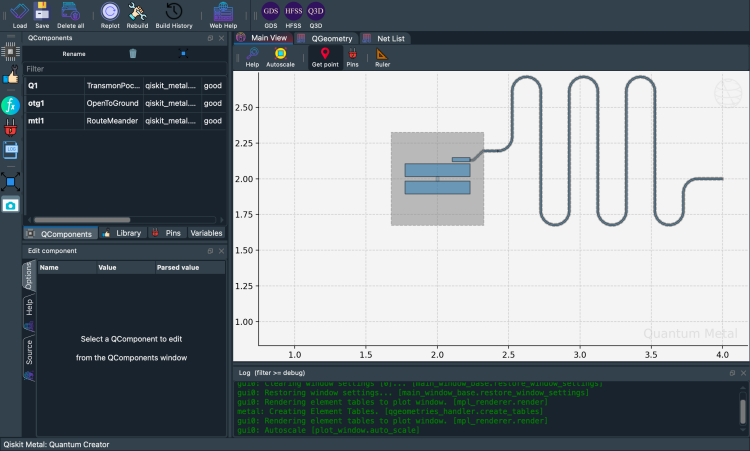

In [7]:
gui.screenshot()
# Headless alternative: import qiskit_metal as qm; qm.view(design)

In [8]:
%metal_heading 2. Rendering your design using `QGmshRenderer`

In [9]:
from qiskit_metal.renderers.renderer_gmsh.gmsh_renderer import QGmshRenderer

# Instantiate QGmshRenderer
gmsh_renderer = QGmshRenderer(design)

### Rendering the wireframe of whole design

In [10]:
# Render the design in Gmsh (wireframe only)
gmsh_renderer.render_design(mesh_geoms=False)

# Launch Gmsh GUI to verify
gmsh_renderer.launch_gui()

Info    : Clearing all models and views...
Info    : Done clearing all models and views
-------------------------------------------------------                                                                   
Version       : 4.15.0
License       : GNU General Public License
Build OS      : MacOSARM-sdk
Build date    : 20251026
Build host    : gmsh.info
Build options : 64Bit ALGLIB[contrib] ANN[contrib] Bamg Blas[petsc] Blossom Cgns DIntegration Dlopen DomHex Eigen[contrib] Fltk GMP Gmm[contrib] Hxt Jpeg Kbipack Lapack[petsc] MathEx[contrib] Med Mesh Metis[contrib] Mpeg Netgen Nii2mesh ONELAB ONELABMetamodel OpenCASCADE OpenCASCADE-CAF OpenGL OpenMP OptHom PETSc Parser Plugins Png Post QuadMeshingTools QuadTri Solver TetGen/BR TinyXML2[contrib] TouchBar Untangle Voro++[contrib] WinslowUntangler Zlib tinyobjloader
FLTK version  : 1.4.0
PETSc version : 3.17.4 (real arithmtic)
OCC version   : 7.8.1
MED version   : 4.1.0
Packaged by   : geuzaine
Web site      : https://gmsh.info
Issue tra

The cell above calls two methods:

- **`render_design(mesh_geoms=False)`** — converts the QDesign geometry into a Gmsh model.
  All metal polygons on the configured layers are imported as Gmsh surfaces.
  Passing `mesh_geoms=False` skips the meshing step so the model loads instantly;
  useful for a quick visual check before committing to a full mesh run.

- **`launch_gui()`** — opens the Gmsh FLTK window shown below.
  The window lets you rotate, zoom, and inspect the geometry in 3-D.
  Use the *Tools → Options* menu to toggle layer visibility or change colours.

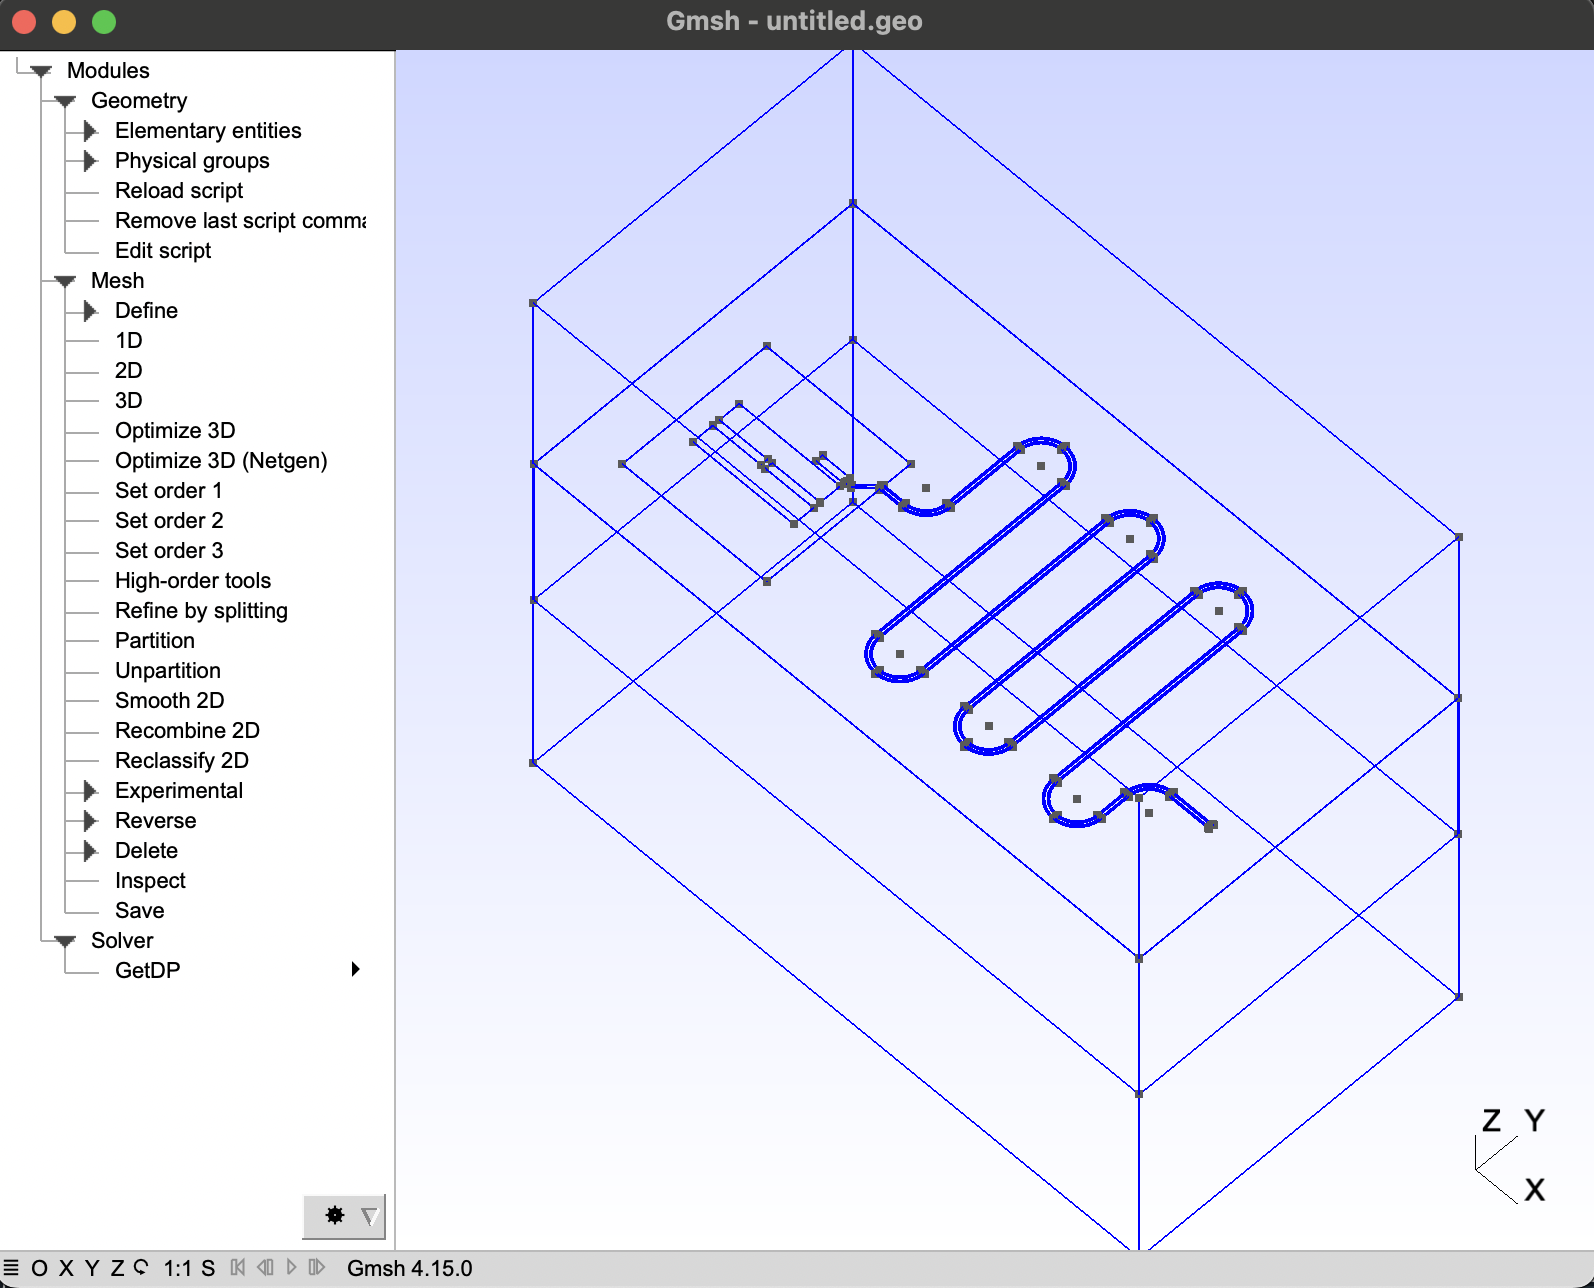

> ⚠️ **`launch_gui()` blocks the kernel.**
> It calls `gmsh.fltk.run()`, which runs the FLTK event loop and does not return
> until you **close the Gmsh window**. The notebook will appear hung while the
> window is open — this is expected. Close the window to continue to the next cell.

In [ ]:
gmsh_renderer.options

### Renderer options

The `gmsh_renderer.options` dict controls geometry import, meshing, and display.
Override any value before calling `render_design`:

```python
gmsh_renderer.options.mesh.max_size = '50um'
```

#### Chip boundary padding

| Option | Default | Meaning |
|--------|---------|--------|
| `x_buffer_width_mm` | `0.2` | Extra margin added around the design bounding box in x (mm) |
| `y_buffer_width_mm` | `0.2` | Extra margin added around the design bounding box in y (mm) |

#### Mesh options (`options.mesh.*`)

| Option | Default | Meaning |
|--------|---------|--------|
| `max_size` | `70 µm` | Maximum allowed edge length anywhere in the mesh |
| `min_size` | `5 µm` | Minimum allowed edge length — sets the floor for refinement |
| `max_size_jj` | `5 µm` | Maximum edge length near Josephson junction geometries (keeps the junction region finely resolved) |
| `smoothing` | `10` | Number of Laplacian smoothing passes applied after meshing |
| `nodes_per_2pi_curve` | `90` | Number of mesh nodes used to approximate a full circle — controls arc fidelity |
| `algorithm_3d` | `10` | Gmsh 3-D algorithm index (10 = HXT, the fast parallel tetrahedral mesher) |
| `num_threads` | `8` | Worker threads for parallel meshing |

#### Size-field options (`options.mesh.mesh_size_fields.*`)

These control a distance-based size field that automatically refines the mesh near
metal edges and coarsens it away from them:

| Option | Default | Meaning |
|--------|---------|--------|
| `min_distance_from_edges` | `10 µm` | Within this distance of a metal edge, `min_size` is used |
| `max_distance_from_edges` | `130 µm` | Beyond this distance, `max_size` is used |
| `distance_delta` | `30 µm` | Sampling resolution for the distance field computation |
| `gradient_delta` | `3 µm` | Controls how steeply the mesh size transitions between `min_size` and `max_size` |

#### Display colours (`options.colors.*`)

RGBA tuples used in the Gmsh GUI (values 0–255):

| Key | Default (R, G, B, A) | Represents |
|-----|----------------------|------------|
| `metal` | (84, 140, 168, 255) | Metal / superconductor surfaces (opaque blue-grey) |
| `jj` | (84, 140, 168, 150) | Josephson junction surfaces (same hue, semi-transparent) |
| `dielectric` | (180, 180, 180, 255) | Dielectric substrate surfaces (opaque light grey) |

### Rendering the components selectively

In [10]:
# Rendering the 'Q1' component
gmsh_renderer.render_design(selection=["Q1"], mesh_geoms=False)
gmsh_renderer.launch_gui()

Info    : Clearing all models and views...
Info    : Done clearing all models and views
-------------------------------------------------------s                                                                                
Version       : 4.15.0
License       : GNU General Public License
Build OS      : MacOSARM-sdk
Build date    : 20251026
Build host    : gmsh.info
Build options : 64Bit ALGLIB[contrib] ANN[contrib] Bamg Blas[petsc] Blossom Cgns DIntegration Dlopen DomHex Eigen[contrib] Fltk GMP Gmm[contrib] Hxt Jpeg Kbipack Lapack[petsc] MathEx[contrib] Med Mesh Metis[contrib] Mpeg Netgen Nii2mesh ONELAB ONELABMetamodel OpenCASCADE OpenCASCADE-CAF OpenGL OpenMP OptHom PETSc Parser Plugins Png Post QuadMeshingTools QuadTri Solver TetGen/BR TinyXML2[contrib] TouchBar Untangle Voro++[contrib] WinslowUntangler Zlib tinyobjloader
FLTK version  : 1.4.0
PETSc version : 3.17.4 (real arithmtic)
OCC version   : 7.8.1
MED version   : 4.1.0
Packaged by   : geuzaine
Web site      : https://gmsh.

FALLBACK (log once): Fallback to SW vertex for line stipple
FALLBACK (log once): Fallback to SW vertex processing, m_disable_code: 2000
FALLBACK (log once): Fallback to SW vertex processing in drawCore, m_disable_code: 2000


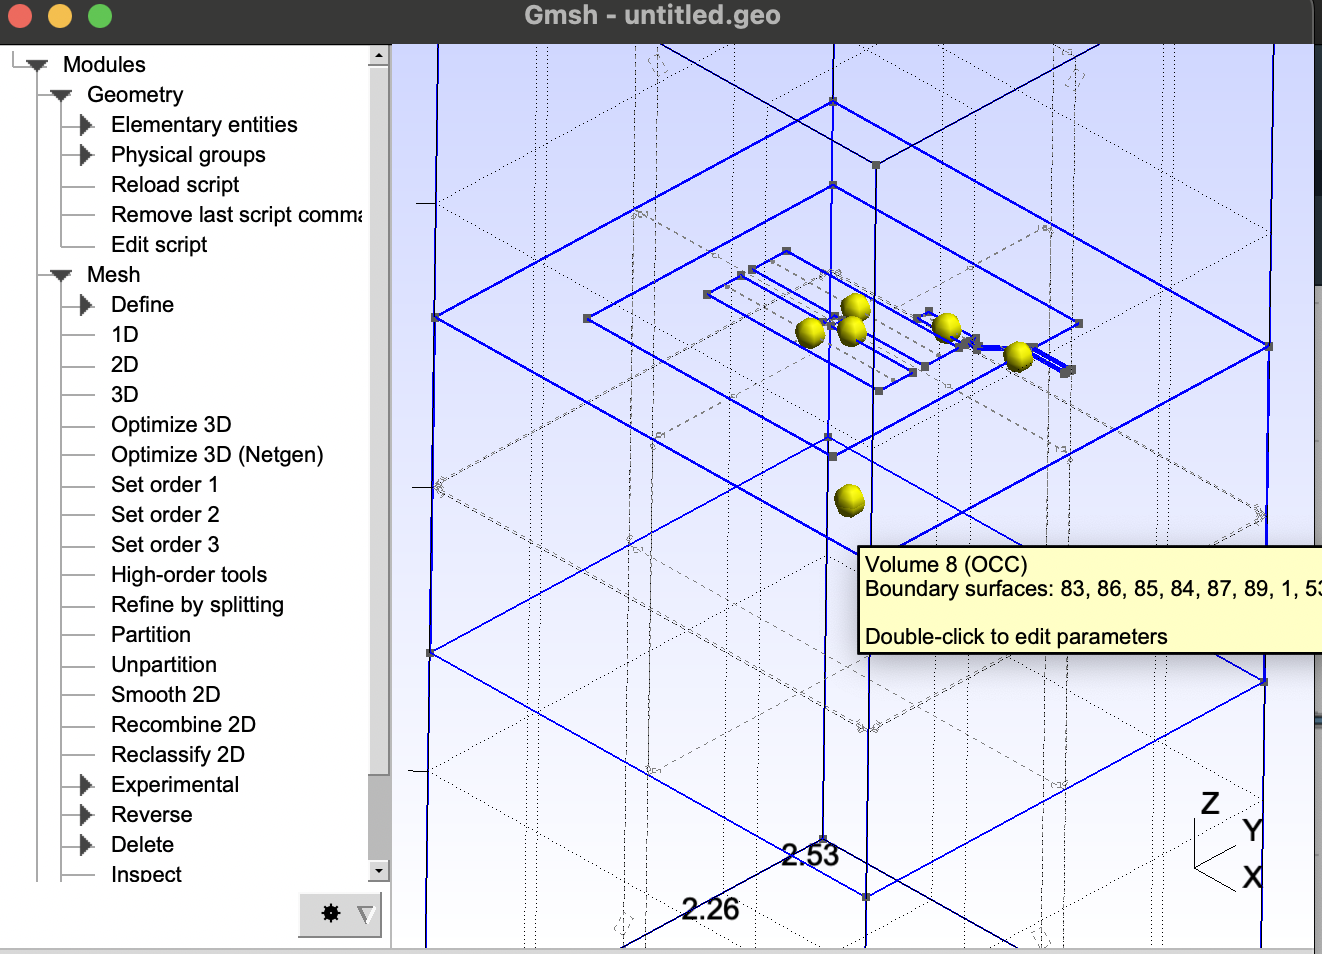

In [ ]:
# Rendering the 'mtl1' component
gmsh_renderer.render_design(selection=["mtl1"], mesh_geoms=False)
gmsh_renderer.launch_gui()

### Defining `open_pins`

`open_pins` adds a small rectangular cap at each listed pin to close the
CPW cross-section for meshing — without it the end of the waveguide is
an open boundary that can confuse the mesher. Each entry is
`(component_name, pin_name)`.

In [11]:
# Rendering the 'Q1' component with open_pins
gmsh_renderer.render_design(
    selection=["Q1"], open_pins=[("Q1", "readout")], mesh_geoms=False
)
gmsh_renderer.launch_gui()

Info    : Clearing all models and views...
Info    : Done clearing all models and views
-------------------------------------------------------                                                                                 
Version       : 4.15.0
License       : GNU General Public License
Build OS      : MacOSARM-sdk
Build date    : 20251026
Build host    : gmsh.info
Build options : 64Bit ALGLIB[contrib] ANN[contrib] Bamg Blas[petsc] Blossom Cgns DIntegration Dlopen DomHex Eigen[contrib] Fltk GMP Gmm[contrib] Hxt Jpeg Kbipack Lapack[petsc] MathEx[contrib] Med Mesh Metis[contrib] Mpeg Netgen Nii2mesh ONELAB ONELABMetamodel OpenCASCADE OpenCASCADE-CAF OpenGL OpenMP OptHom PETSc Parser Plugins Png Post QuadMeshingTools QuadTri Solver TetGen/BR TinyXML2[contrib] TouchBar Untangle Voro++[contrib] WinslowUntangler Zlib tinyobjloader
FLTK version  : 1.4.0
PETSc version : 3.17.4 (real arithmtic)
OCC version   : 7.8.1
MED version   : 4.1.0
Packaged by   : geuzaine
Web site      : https://gmsh.

### Skipping the junction

Set `skip_junctions=True` to omit the Josephson junction geometry from the
Gmsh model. This is useful when you want to mesh the electromagnetic
environment of the qubit without modelling the junction bridge itself
(e.g. for eigenmode analysis where the junction is treated as a lumped element).

In [ ]:
# Rendering the 'Q1' component without the junction
gmsh_renderer.render_design(selection=["Q1"], mesh_geoms=False, skip_junctions=True)
gmsh_renderer.launch_gui()

In [ ]:
%metal_heading 3. Meshing your design using `QGmshRenderer`

### Applying a basic mesh to your design
Run the code below, then in the Gmsh app window do the following to see the mesh on the chip
1. In the menu bar on top, go to `Tools > Visibility`
1. In the visbility settings window, click on the drop-down and select `Physical Groups`
1. Press Ctrl-key (or Command-key on MacOS) and select everything except the ones having `vacuum_box...` in their name.
1. Click on Apply, and close the visibility settings window.
1. In the main Gmsh window, right click and go to `Mesh Visibility`, and select the option `2D element faces`
1. This will make your chip's mesh visible.

In [6]:
# meshing the whole design
gmsh_renderer.render_design(mesh_geoms=False)
gmsh_renderer.add_mesh(intelli_mesh=False)
gmsh_renderer.launch_gui()

Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Meshing 1D...nts - Making faces                                                                                 
Info    : [  0%] Meshing curve 469 (Line)
Info    : [  0%] Meshing curve 888 (Line)
Info    : [  0%] Meshing curve 709 (Line)
Info    : [  0%] Meshing curve 589 (Circle)
Info    : [  0%] Meshing curve 529 (Line)
Info    : [  0%] Meshing curve 649 (Line)
Info    : [  0%] Meshing curve 829 (Line)
Info    : [  0%] Meshing curve 769 (Line)
Info    : [  0%] Meshing curve 710 (Line)
Info    : [ 10%] Meshing curve 470 (Line)
Info    : [ 10%] Meshing curve 770 (Line)
Info    : [ 10%] Meshing curve 889 (Line)
Info    : [ 10%] Meshing curve 530 (Line)
Info    : [ 10%] Meshing curve 471 (Line)
Info    : [ 10%] Meshing curve 830 (Line)
Info    : [ 10%] Meshing curve 590 (Line)
Info    : [ 10%] Meshing curve 472 (Line)
Info    : [ 10%] Meshing curve 531 (Line)
Info    : [ 10%] Meshing curve 

With only the 2D surface mesh 
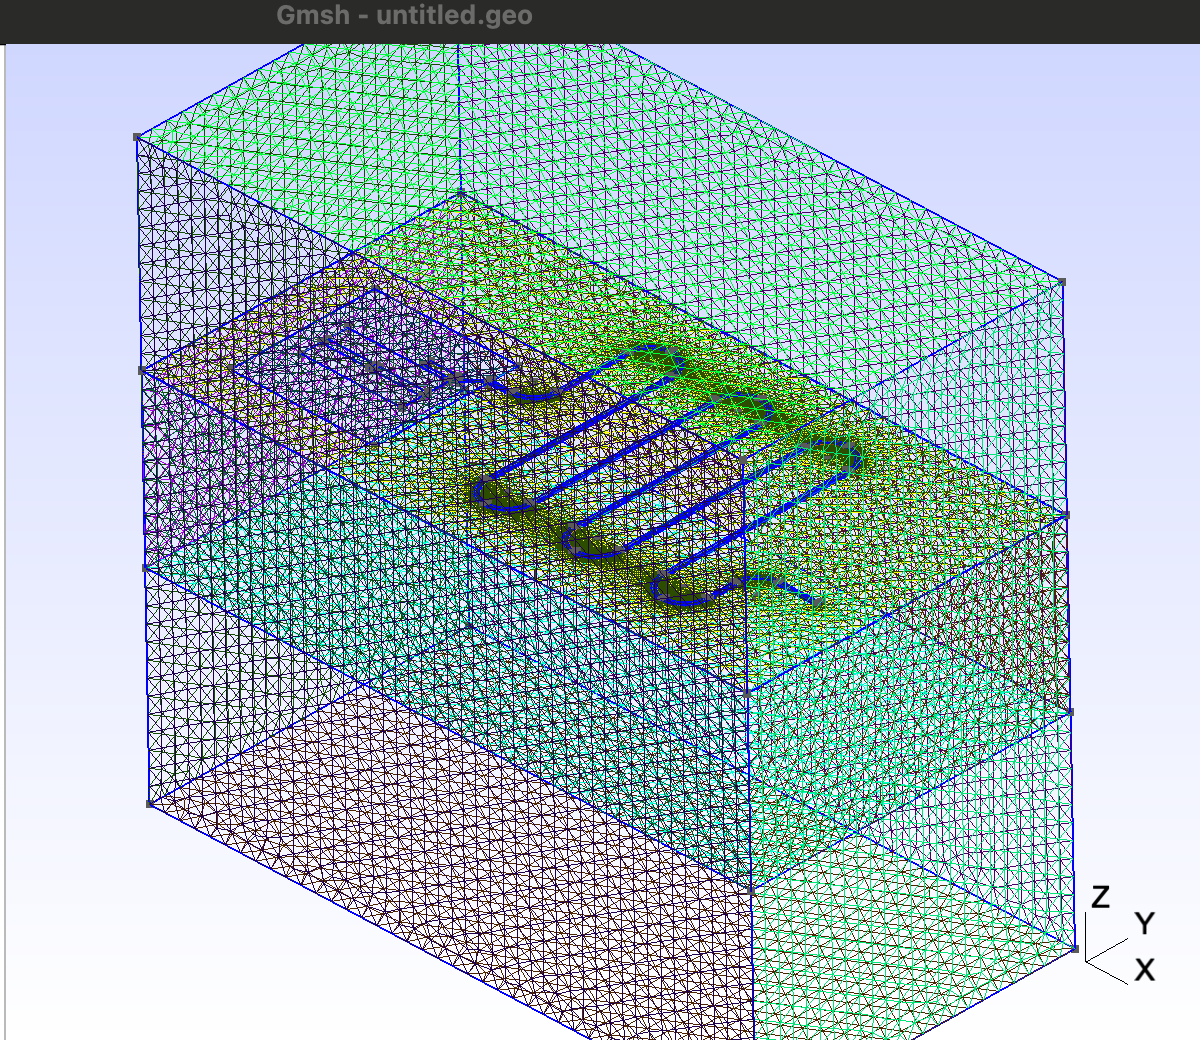

### Customising the mesh using initial mesh size parameters

Setting a global `max_size` forces Gmsh to use at most that edge length
everywhere. Smaller values produce more accurate results but cost more
memory and time:

| max_size | Typical use | Memory (this design) |
|----------|-------------|---------------------|
| `70 µm` | Quick geometry check | < 100 MB |
| `20 µm` | Moderate accuracy | ~500 MB–1 GB |
| `5 µm` | High accuracy / tapeout | > 4 GB |

> ⚠️ Setting `max_size` below `10 µm` on a full chip can exhaust RAM on most
> laptops. Use the **Intelli-mesh** feature in the next section to get fine
> resolution only near metal edges without meshing the entire chip finely.

In [ ]:
# Setting initial mesh size constraints (might take a while to run!!)
# DISCLAIMER: this might also crash if your system has less than 8GB of memory
gmsh_renderer.options.mesh.max_size = "20um"
gmsh_renderer.options.mesh.min_size = "5um"
gmsh_renderer.render_design(mesh_geoms=False)
gmsh_renderer.add_mesh(intelli_mesh=False)
gmsh_renderer.launch_gui()

### Using the Intelli-mesh feature
As we observe from the previous cell, just setting the intial mesh size constraints to a small value is very computationally intensive and requires a lot of memory. Hence, in a practical scenario we try to increase the mesh density in the regions which are of critical importance and decrease the mesh density where it does not matter much.

In `QGmshRenderer`, we have a semi-automatic way of meshing the design taking the assumption that the electric and magnetic fields would always be concentrated at the edges of metals and at the metal-dielectric interfaces. This whole thing is wrapped up neatly in a feature that we call **Intelli-mesh**!

In [ ]:
# Intelli-mesh is ON by default and will work
# automatically when calling the render_design() method
gmsh_renderer.options.mesh.max_size = "70um"
gmsh_renderer.options.mesh.min_size = "5um"
gmsh_renderer.render_design()
gmsh_renderer.launch_gui()

### **Advanced:** defining your own custom meshing function
This is only for advanced users who are aware of how Gmsh works and how to specify the mesh size fields for Gmsh.

In [ ]:
# Define a function to specify custom mesh density field across your design
def my_custom_meshing_function():

    # Selectively increase mesh density for the following QGeometries
    q1_top_pad = gmsh_renderer.polys_dict[1]["Q1_pad_top"][0]
    q1_readout_wire = gmsh_renderer.paths_dict[1]["Q1_readout_wire"][0]

    # Extract surfaces from Gmsh volume tags
    volumes_list = [q1_top_pad, q1_readout_wire]
    surfaces = []
    for vol in volumes_list:
        surfaces += [
            tag for tag in gmsh_renderer.modeler.occ.getSurfaceLoops(vol)[1][0]
        ]

    # Extract min and max mehs size constraints from the renderer
    min_size = gmsh_renderer.parse_units_gmsh(gmsh_renderer.options.mesh.min_size)
    max_size = gmsh_renderer.parse_units_gmsh(gmsh_renderer.options.mesh.max_size)

    # Define Gmsh fields
    # Field: Distance
    df = gmsh_renderer.modeler.mesh.field.add("Distance")
    gmsh_renderer.modeler.mesh.field.setNumbers(df, "SurfacesList", surfaces)
    gmsh_renderer.modeler.mesh.field.setNumber(df, "NumPointsPerCurve", 100)

    # Field: Threshold
    tf = gmsh_renderer.modeler.mesh.field.add("Threshold")
    gmsh_renderer.modeler.mesh.field.setNumber(tf, "DistMin", 0.01)
    gmsh_renderer.modeler.mesh.field.setNumber(tf, "DistMax", 0.07)
    gmsh_renderer.modeler.mesh.field.setNumber(tf, "Sigmoid", 1)
    gmsh_renderer.modeler.mesh.field.setNumber(tf, "InField", df)
    gmsh_renderer.modeler.mesh.field.setNumber(tf, "SizeMin", min_size)
    gmsh_renderer.modeler.mesh.field.setNumber(tf, "SizeMax", max_size)

    # Set as background mesh to generate the mesh
    gmsh_renderer.modeler.mesh.field.setAsBackgroundMesh(tf)

In [ ]:
# define initial mesh sizes
gmsh_renderer.options.mesh.max_size = "70um"
gmsh_renderer.options.mesh.min_size = "5um"

# render design wireframe
gmsh_renderer.render_design(selection=["Q1"], mesh_geoms=False)

# Pass your custom mehsing function to add_mesh()
gmsh_renderer.add_mesh(intelli_mesh=True, custom_mesh_fn=my_custom_meshing_function)
gmsh_renderer.launch_gui()

In [ ]:
%metal_heading 4. Exporting your mesh to a file

### Use `QGmshRenderer` to export the generated mesh to a file

In [ ]:
# Export the mesh to a file.
# Supported extensions: .msh, .msh2, .mesh
gmsh_renderer.export_mesh("test.msh")

import pathlib

msh = pathlib.Path("test.msh")
print(
    f"Exported: {msh.name}  ({msh.stat().st_size / 1024:.1f} kB)"
    if msh.exists()
    else "Export failed — check Gmsh log above"
)

In [ ]:
# Close and destroy the renderer object
gmsh_renderer.close()

In [ ]:
# Uncomment to close the Metal GUI window:
# gui.main_window.close()